# 🏥 Early Disease Prediction Using Healthcare Data Warehouse
### Complete Project Dashboard — All Phases in One Notebook

| Phase | Script / Notebook | Description |
|---|---|---|
| **0 — Inspect** | `etl_pipeline/load_and_inspect.py` | Raw data audit |
| **1A — Clean** | `etl_pipeline/clean.py` | ETL cleaning & encoding |
| **1B — Warehouse** | `etl_pipeline/warehouse.py` | SQLite Star Schema |
| **2 — EDA** | `eda/02_eda.ipynb` | 14 figures + statistical tests |
| **3 — Features** | `models/03_feature_engineering.ipynb` | SMOTE · Scaling · Splits |
| **4 — Models** | `models/04_modeling.ipynb` | 5 classifiers × 3 diseases |
| **SQL** | `warehouse/03_sql_analysis.ipynb` | 20 OLAP queries |

> **How to use this notebook:**
> Run every cell top-to-bottom with **Kernel → Restart & Run All**.
> Each section first checks whether its artefacts already exist and skips
> re-running if they do — making the notebook fast on subsequent opens.

In [1]:
import os, sys, warnings, subprocess, sqlite3, glob, time
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.image     as mpimg
import matplotlib.gridspec  as gridspec
import seaborn  as sns
import joblib
from pathlib import Path

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'      : 110,
    'figure.facecolor': 'white',
    'axes.titleweight': 'bold',
    'axes.titlesize'  : 12,
})

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT    = Path.cwd()
ETL     = ROOT / 'etl_pipeline'
CLEANED = ROOT / 'datasets'  / 'cleaned'
WH_DIR  = ROOT / 'warehouse'
EDA_DIR = ROOT / 'eda'
MDL_DIR = ROOT / 'models'
SAVED   = ROOT / 'models'    / 'saved'
FIGS    = ROOT / 'reports'   / 'figures'
DB      = WH_DIR / 'health_warehouse.db'

def run_script(script_path: Path) -> None:
    """Run a Python script and stream its stdout to the notebook cell."""
    result = subprocess.run(
        [sys.executable, str(script_path)],
        capture_output=False,
        text=True,
        cwd=str(ROOT),
    )
    if result.returncode != 0:
        print(f"  [ERROR] {script_path.name} exited with code {result.returncode}")

def show_images(paths: list, cols: int = 3, figsize_per: float = 5.0) -> None:
    """Display a list of image files in a grid."""
    n    = len(paths)
    if n == 0:
        print("  No figures found.")
        return
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * figsize_per, rows * figsize_per))
    axes = np.array(axes).reshape(-1)
    for ax, path in zip(axes, paths):
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(Path(path).stem.replace('_', ' '), fontsize=9, pad=4)
    for ax in axes[n:]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print(f"ROOT : {ROOT}")
print()
print("Artefact check:")
checks = {
    'datasets/cleaned/autism_cleaned.csv'   : CLEANED / 'autism_cleaned.csv',
    'datasets/cleaned/diabetes_cleaned.csv' : CLEANED / 'diabetes_cleaned.csv',
    'datasets/cleaned/stroke_cleaned.csv'   : CLEANED / 'stroke_cleaned.csv',
    'warehouse/health_warehouse.db'         : DB,
    'models/saved/autism_artifacts.pkl'     : SAVED / 'autism_artifacts.pkl',
    'models/saved/stroke_artifacts.pkl'     : SAVED / 'stroke_artifacts.pkl',
    'models/saved/autism_best_model.pkl'    : SAVED / 'autism_best_model.pkl',
    'models/saved/stroke_best_model.pkl'    : SAVED / 'stroke_best_model.pkl',
}
all_ready = True
for label, path in checks.items():
    exists = path.exists()
    if not exists: all_ready = False
    print(f"  {'[OK]' if exists else '[MISSING]':<10} {label}")
print()
print("All artefacts present — you can run in READ-ONLY mode." if all_ready
      else "Some artefacts missing — run Phase sections below to generate them.")

ROOT : D:\NMU\Data Mining\datamining_project

Artefact check:
  [OK]       datasets/cleaned/autism_cleaned.csv
  [OK]       datasets/cleaned/diabetes_cleaned.csv
  [OK]       datasets/cleaned/stroke_cleaned.csv
  [OK]       warehouse/health_warehouse.db
  [OK]       models/saved/autism_artifacts.pkl
  [OK]       models/saved/stroke_artifacts.pkl
  [OK]       models/saved/autism_best_model.pkl
  [OK]       models/saved/stroke_best_model.pkl

All artefacts present — you can run in READ-ONLY mode.


---
## Phase 0 · Raw Data Inspection

Audit the three original CSV files — shapes, column types, and missing values —
**without modifying anything**.  The raw files in `datasets/` are never touched.

In [2]:
print("Running load_and_inspect.py ...")
print("-" * 60)
run_script(ETL / 'load_and_inspect.py')

Running load_and_inspect.py ...
------------------------------------------------------------


---
## Phase 1A · ETL Cleaning  (`clean.py`)

Applies all dataset-specific cleaning rules and saves three cleaned CSVs to
`datasets/cleaned/`.

| Dataset | Key Transformations |
|---|---|
| **Autism** | Fix `Jauundice` typo · encode binary cols · engineer `AQ_Score` |
| **Diabetes** | Encode 14 Yes/No symptoms · rename target column |
| **Stroke** | Drop `id` · drop `Other` gender row · **grouped-median BMI imputation** |

In [3]:
if all(p.exists() for p in [CLEANED/'autism_cleaned.csv',
                              CLEANED/'diabetes_cleaned.csv',
                              CLEANED/'stroke_cleaned.csv']):
    print("Cleaned CSVs already exist — skipping re-run.")
    print("(Delete datasets/cleaned/ and re-run this cell to force re-cleaning.)")
else:
    print("Running clean.py ...")
    run_script(ETL / 'clean.py')

print()
print("Cleaned dataset summary:")
summary_rows = []
for name, fname in [('Autism Screening', 'autism_cleaned.csv'),
                    ('Diabetes Risk',    'diabetes_cleaned.csv'),
                    ('Stroke Prediction','stroke_cleaned.csv')]:
    f  = CLEANED / fname
    if f.exists():
        df = pd.read_csv(f)
        pos = (df['Class'] == 1).sum()
        neg = (df['Class'] == 0).sum()
        summary_rows.append({
            'Dataset'        : name,
            'Rows'           : df.shape[0],
            'Cols'           : df.shape[1],
            'Positive (1)'   : pos,
            'Negative (0)'   : neg,
            'Pos %'          : f"{pos/len(df)*100:.1f}%",
            'Imbalance Ratio': f"1 : {neg/pos:.1f}",
            'Missing Cells'  : df.isnull().sum().sum(),
        })

pd.set_option('display.max_colwidth', 30)
summary = pd.DataFrame(summary_rows).set_index('Dataset')
display(summary)

Cleaned CSVs already exist — skipping re-run.
(Delete datasets/cleaned/ and re-run this cell to force re-cleaning.)

Cleaned dataset summary:


,Rows,Cols,Positive (1),Negative (0),Pos %,Imbalance Ratio,Missing Cells
Dataset,,,,,,,
Autism Screening,6075,16,1804,4271,29.7%,1 : 2.4,0
Diabetes Risk,520,17,320,200,61.5%,1 : 0.6,0
Stroke Prediction,5109,11,249,4860,4.9%,1 : 19.5,0


In [4]:
# ── Quick sample view ────────────────────────────────────────────────────────
print("Sample rows from each cleaned dataset:")
for name, fname in [('Autism', 'autism_cleaned.csv'),
                    ('Diabetes', 'diabetes_cleaned.csv'),
                    ('Stroke', 'stroke_cleaned.csv')]:
    f = CLEANED / fname
    if f.exists():
        print(f"\n--- {name} ---")
        display(pd.read_csv(f).head(3))

Sample rows from each cleaned dataset:

--- Autism ---


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Class,AQ_Score
0,1,1,0,1,0,0,1,1,0,0,15,1,0,0,0,5
1,0,1,1,1,0,1,1,0,1,0,15,1,0,0,0,6
2,1,1,1,0,1,1,1,1,1,1,15,0,0,1,1,9



--- Diabetes ---


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,Class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1



--- Stroke ---


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,Class
0,1,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1
1,0,61.0,0,0,1,Self-employed,0,202.21,29.3,never smoked,1
2,1,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1


---
## Phase 1B · Data Warehouse  (`warehouse.py`)

Builds the **SQLite Star Schema** with explicit raw SQL `CREATE TABLE`
statements.  The schema is:

```
dim_patient  (PK: patient_id AUTO)
    ├── fact_autism    (FK → patient_id, 15 features + label)
    ├── fact_diabetes  (FK → patient_id, 14 symptoms + label)
    └── fact_stroke    (FK → patient_id,  9 features + label)
```

All three fact tables use `ON DELETE CASCADE`.

In [5]:
if DB.exists():
    print("Warehouse already exists — skipping re-build.")
    print("(Delete warehouse/health_warehouse.db to force rebuild.)")
else:
    print("Running warehouse.py ...")
    run_script(ETL / 'warehouse.py')

# ── Live stats from the DB ────────────────────────────────────────────────────
if DB.exists():
    conn = sqlite3.connect(DB)
    print()
    print("Live row counts from health_warehouse.db:")
    wh_rows = []
    for tbl, ttype in [('dim_patient','DIMENSION'),
                       ('fact_autism','FACT'),
                       ('fact_diabetes','FACT'),
                       ('fact_stroke','FACT')]:
        n    = conn.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
        cols = len(conn.execute(f"PRAGMA table_info({tbl})").fetchall())
        wh_rows.append({'Table': tbl, 'Type': ttype,
                        'Rows': f"{n:,}", 'Columns': cols})
    display(pd.DataFrame(wh_rows).set_index('Table'))

    # FK integrity
    orphans = {
        'fact_autism'  : "SELECT COUNT(*) FROM fact_autism   fa LEFT JOIN dim_patient dp ON fa.patient_id=dp.patient_id WHERE dp.patient_id IS NULL",
        'fact_diabetes': "SELECT COUNT(*) FROM fact_diabetes fd LEFT JOIN dim_patient dp ON fd.patient_id=dp.patient_id WHERE dp.patient_id IS NULL",
        'fact_stroke'  : "SELECT COUNT(*) FROM fact_stroke   fs LEFT JOIN dim_patient dp ON fs.patient_id=dp.patient_id WHERE dp.patient_id IS NULL",
    }
    print()
    print("Referential integrity (FK orphan check):")
    for tbl, sql in orphans.items():
        n = conn.execute(sql).fetchone()[0]
        print(f"  {'[PASS]' if n==0 else '[FAIL]'}  {tbl}: {n} orphans")

    conn.close()

Warehouse already exists — skipping re-build.
(Delete warehouse/health_warehouse.db to force rebuild.)

Live row counts from health_warehouse.db:


,Type,Rows,Columns
Table,,,
dim_patient,DIMENSION,"11,704",4
fact_autism,FACT,"6,075",16
fact_diabetes,FACT,520,17
fact_stroke,FACT,"5,109",11



Referential integrity (FK orphan check):
  [PASS]  fact_autism: 0 orphans
  [PASS]  fact_diabetes: 0 orphans
  [PASS]  fact_stroke: 0 orphans


---
## Phase 2 · Exploratory Data Analysis

Key EDA figures saved in `reports/figures/`.
The full interactive EDA notebook is at `eda/02_eda.ipynb`.

**Highlights:**
- Class imbalance audit across all 3 diseases
- AQ-10 item heatmap (autism)
- Symptom prevalence ranking (diabetes)
- Stroke risk by smoking status & comorbidities
- 14 statistical tests (Chi-square + Mann-Whitney U)

Displaying 6 key EDA figures:


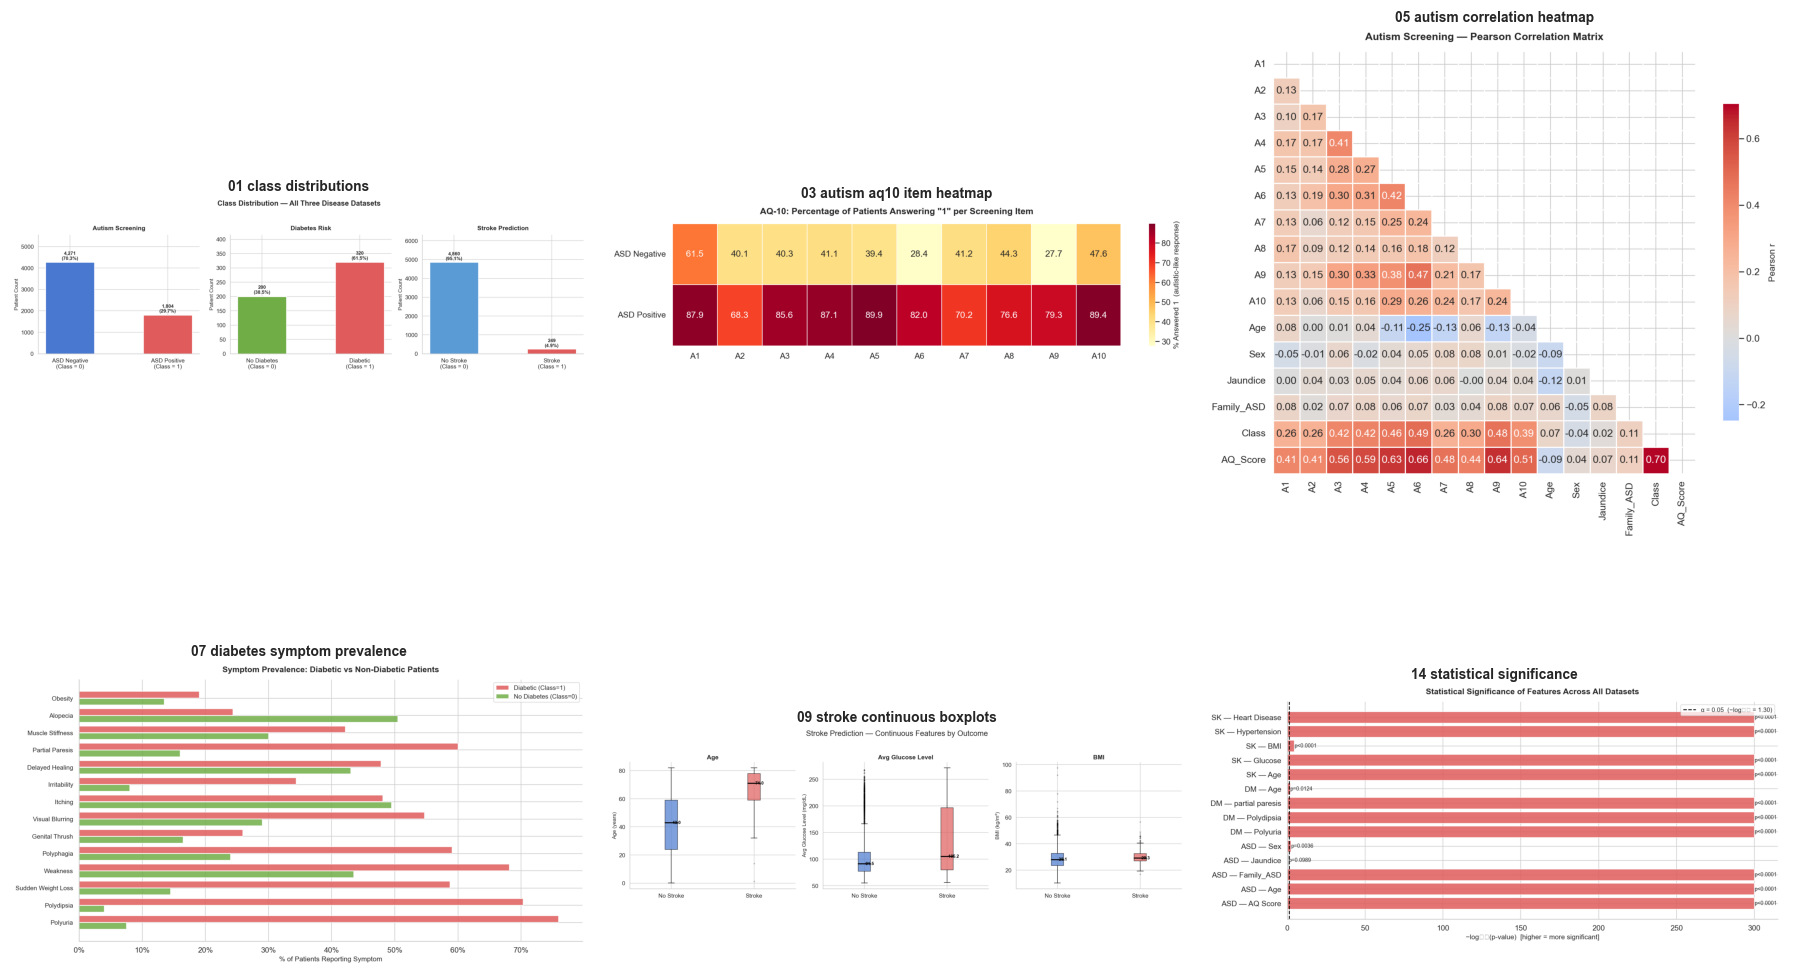

In [6]:
# ── Show the 6 most important EDA figures ───────────────────────────────────
key_eda = [
    '01_class_distributions.png',
    '03_autism_aq10_item_heatmap.png',
    '05_autism_correlation_heatmap.png',
    '07_diabetes_symptom_prevalence.png',
    '09_stroke_continuous_boxplots.png',
    '14_statistical_significance.png',
]
paths = [str(FIGS / f) for f in key_eda if (FIGS / f).exists()]
if paths:
    print(f"Displaying {len(paths)} key EDA figures:")
    show_images(paths, cols=3, figsize_per=5.5)
else:
    print("EDA figures not found. Run eda/02_eda.ipynb first.")

Full EDA Gallery — 14 figures:


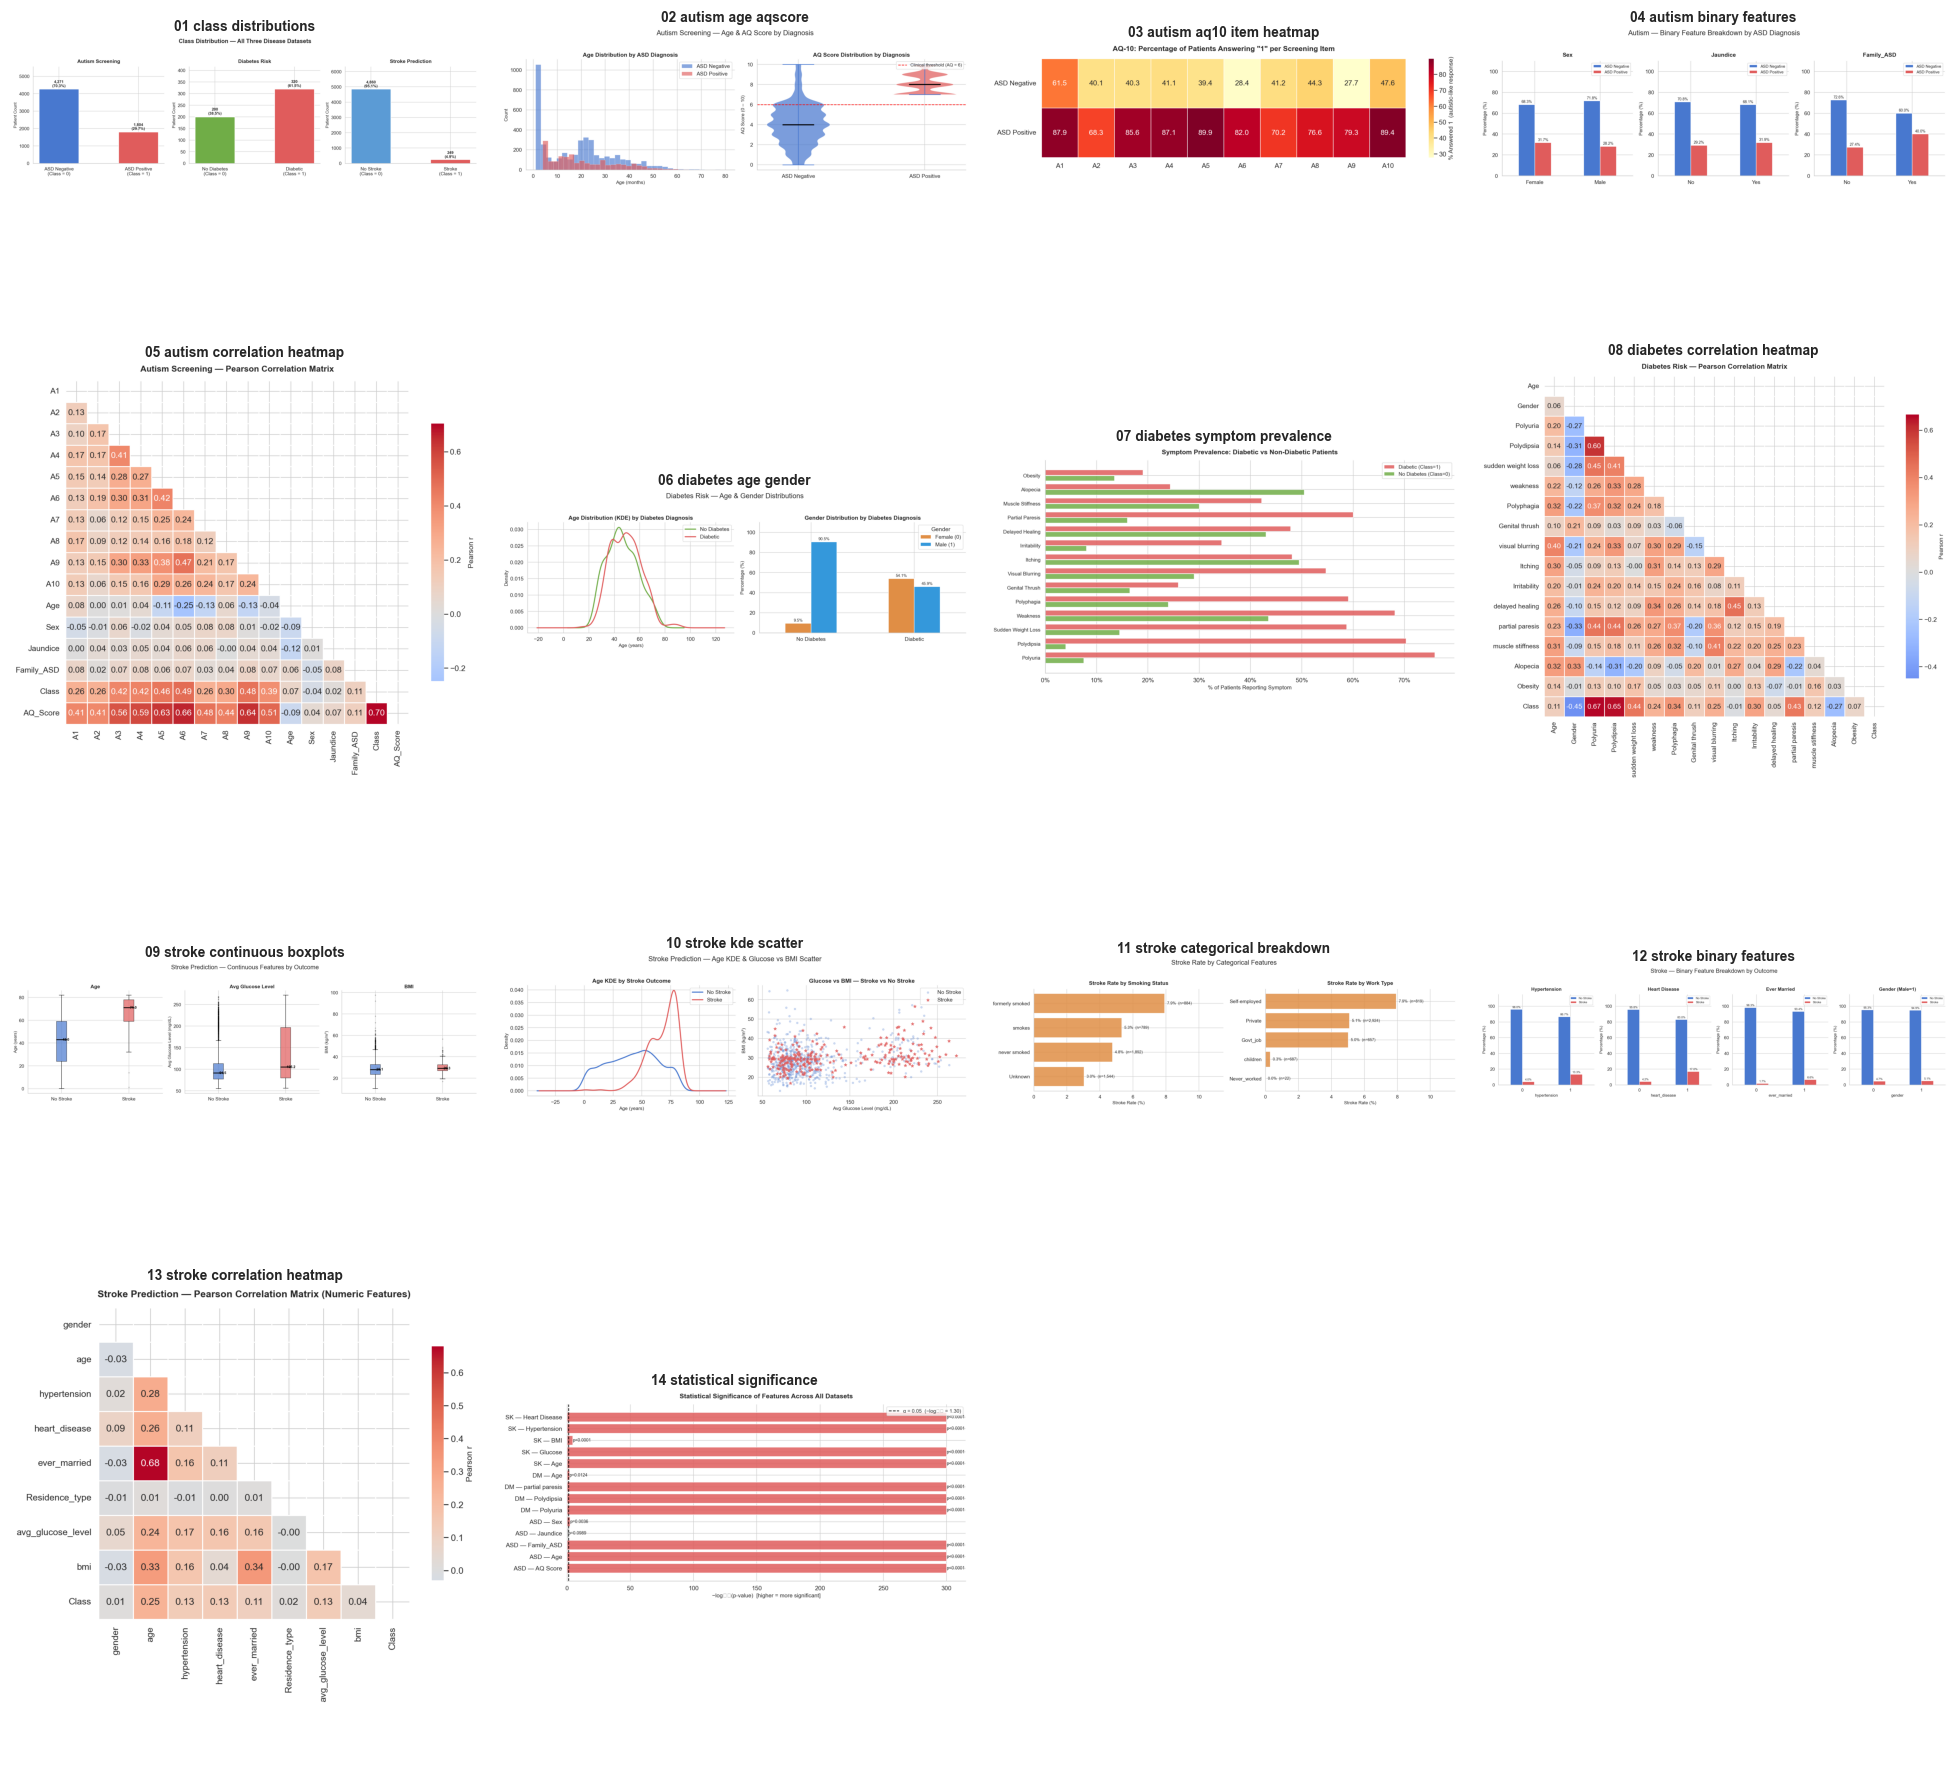

In [7]:
# ── Full figure gallery (all EDA figures 01–14) ─────────────────────────────
all_eda_figs = sorted(
    [str(p) for p in FIGS.glob('*.png')
     if int(p.stem.split('_')[0]) <= 14],
    key=lambda x: int(Path(x).stem.split('_')[0])
)
if all_eda_figs:
    print(f"Full EDA Gallery — {len(all_eda_figs)} figures:")
    show_images(all_eda_figs, cols=4, figsize_per=4.5)

---
## Phase 3 · Feature Engineering

All preprocessing artifacts are pre-saved in `models/saved/`.
The full notebook is at `models/03_feature_engineering.ipynb`.

| Dataset | Train | Test | Features | Imbalance Strategy |
|---|---|---|---|---|
| Autism | 4,860 | 1,215 | 15 | `class_weight='balanced'` |
| Diabetes | 416 | 104 | 16 | `class_weight='balanced'` |
| Stroke | 4,087+SMOTE | 1,022 | 15 | SMOTE → 7,776 balanced samples |

Feature Engineering Artifacts Summary:


,X_train shape,X_test shape,Features,Pos in train,Neg in train,SMOTE
Dataset,,,,,,
Autism,"(4860, 15)","(1215, 15)",15,1443,3417,Not applied
Diabetes,"(416, 16)","(104, 16)",16,256,160,Not applied
Stroke,"(4087, 15)","(1022, 15)",15,199,3888,"SMOTE → 7,776 samples"



Feature importance figures:


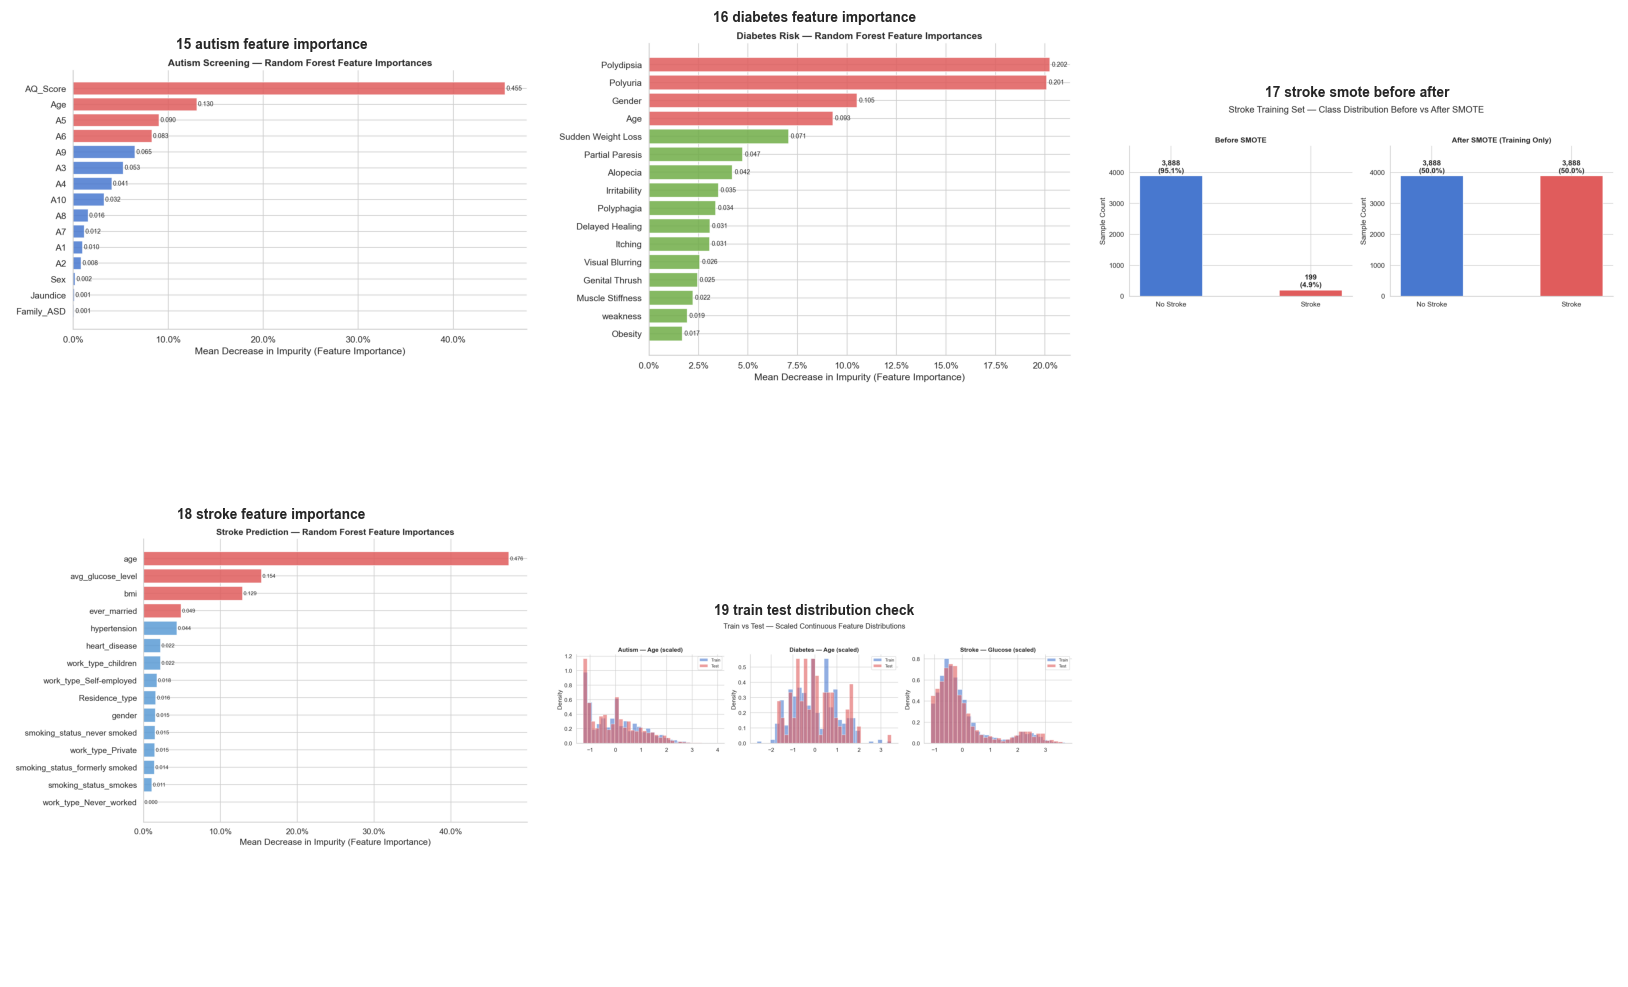

In [8]:
art_files = {
    'Autism'  : SAVED / 'autism_artifacts.pkl',
    'Diabetes': SAVED / 'diabetes_artifacts.pkl',
    'Stroke'  : SAVED / 'stroke_artifacts.pkl',
}

if all(p.exists() for p in art_files.values()):
    print("Feature Engineering Artifacts Summary:")
    fe_rows = []
    for ds, path in art_files.items():
        art = joblib.load(path)
        X_tr = art['X_train']
        X_te = art['X_test']
        y_tr = art['y_train']
        smote_info = ''
        if 'X_train_smote' in art:
            smote_info = f"SMOTE → {art['X_train_smote'].shape[0]:,} samples"
        fe_rows.append({
            'Dataset'       : ds,
            'X_train shape' : str(X_tr.shape),
            'X_test shape'  : str(X_te.shape),
            'Features'      : X_tr.shape[1],
            'Pos in train'  : int(y_tr.sum()),
            'Neg in train'  : int((y_tr==0).sum()),
            'SMOTE'         : smote_info if smote_info else 'Not applied',
        })
    display(pd.DataFrame(fe_rows).set_index('Dataset'))

    print()
    print("Feature importance figures:")
    fi_figs = sorted(
        [str(p) for p in FIGS.glob('1[5-9]_*.png')],
        key=lambda x: int(Path(x).stem.split('_')[0])
    )
    if fi_figs:
        show_images(fi_figs, cols=3, figsize_per=5.0)
else:
    print("Artifacts not found. Run models/03_feature_engineering.ipynb first.")

---
## Phase 4 · Model Training & Evaluation

Five classifiers trained on each of the three disease datasets.

**Primary metrics used:**
- **Autism / Diabetes**: F1-Score, ROC-AUC, MCC
- **Stroke**: Recall + PR-AUC  *(a missed stroke = a preventable death)*

> The stroke model achieves **Recall = 0.82** — identifying 82% of all actual
> stroke patients — despite a 19.5 : 1 class imbalance.

In [9]:
result_files = {
    'Autism Screening' : SAVED / 'autism_results.csv',
    'Diabetes Risk'    : SAVED / 'diabetes_results.csv',
    'Stroke Prediction': SAVED / 'stroke_results.csv',
}

if all(p.exists() for p in result_files.values()):
    KEY_METRICS = ['CV F1', 'F1', 'Recall', 'Precision',
                   'ROC-AUC', 'PR-AUC', 'MCC']

    for ds_name, csv_path in result_files.items():
        df_r = pd.read_csv(csv_path, index_col=0)
        available = [c for c in KEY_METRICS if c in df_r.columns]
        print(f"\n{'='*60}")
        print(f"  {ds_name}")
        print(f"{'='*60}")
        styled = (df_r[available]
                  .style
                  .highlight_max(axis=0, color='#c6efce')
                  .highlight_min(axis=0, color='#ffc7ce',
                                 subset=['CV F1'] if 'CV F1' in available else [])
                  .format(precision=4))
        display(styled)
else:
    print("Results CSVs not found. Run models/04_modeling.ipynb first.")


  Autism Screening


,CV F1,F1,Recall,Precision,ROC-AUC,PR-AUC,MCC
Model,,,,,,,
Logistic Regression,0.8844,0.8561,0.9307,0.7925,0.9561,0.8615,0.7936
Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



  Diabetes Risk


,CV F1,F1,Recall,Precision,ROC-AUC,PR-AUC,MCC
Model,,,,,,,
Logistic Regression,0.9090,0.9333,0.8750,1.0000,0.9914,0.9949,0.8539
Decision Tree,0.9076,0.9333,0.8750,1.0000,0.9957,0.9966,0.8539
Random Forest,0.9607,0.9841,0.9688,1.0000,1.0000,1.0000,0.9605
XGBoost,0.9717,0.9760,0.9531,1.0000,0.9996,0.9998,0.9416
LightGBM,0.9640,0.9841,0.9688,1.0000,1.0000,1.0000,0.9605



  Stroke Prediction


,CV F1,F1,Recall,Precision,ROC-AUC,PR-AUC,MCC
Model,,,,,,,
Logistic Regression,0.7952,0.2303,0.8200,0.1340,0.8397,0.2746,0.2578
Decision Tree,0.8931,0.1333,0.1200,0.1500,0.7129,0.1070,0.0946
Random Forest,0.9632,0.2090,0.1400,0.4118,0.7762,0.2112,0.2188
XGBoost,0.9681,0.1754,0.1000,0.7143,0.7905,0.2307,0.2562
LightGBM,0.9710,0.0968,0.0600,0.2500,0.7903,0.1848,0.1016


In [10]:
# ── Best model per disease ───────────────────────────────────────────────────
best_models = {
    'Autism'  : SAVED / 'autism_best_model.pkl',
    'Diabetes': SAVED / 'diabetes_best_model.pkl',
    'Stroke'  : SAVED / 'stroke_best_model.pkl',
}
print("Best saved model per disease:")
for ds, path in best_models.items():
    if path.exists():
        model = joblib.load(path)
        print(f"  {ds:<12}  {type(model).__name__}")
    else:
        print(f"  {ds:<12}  [NOT FOUND]")

Best saved model per disease:


  Autism        DecisionTreeClassifier


  Diabetes      RandomForestClassifier
  Stroke        LogisticRegression


Model evaluation figures (9 total):


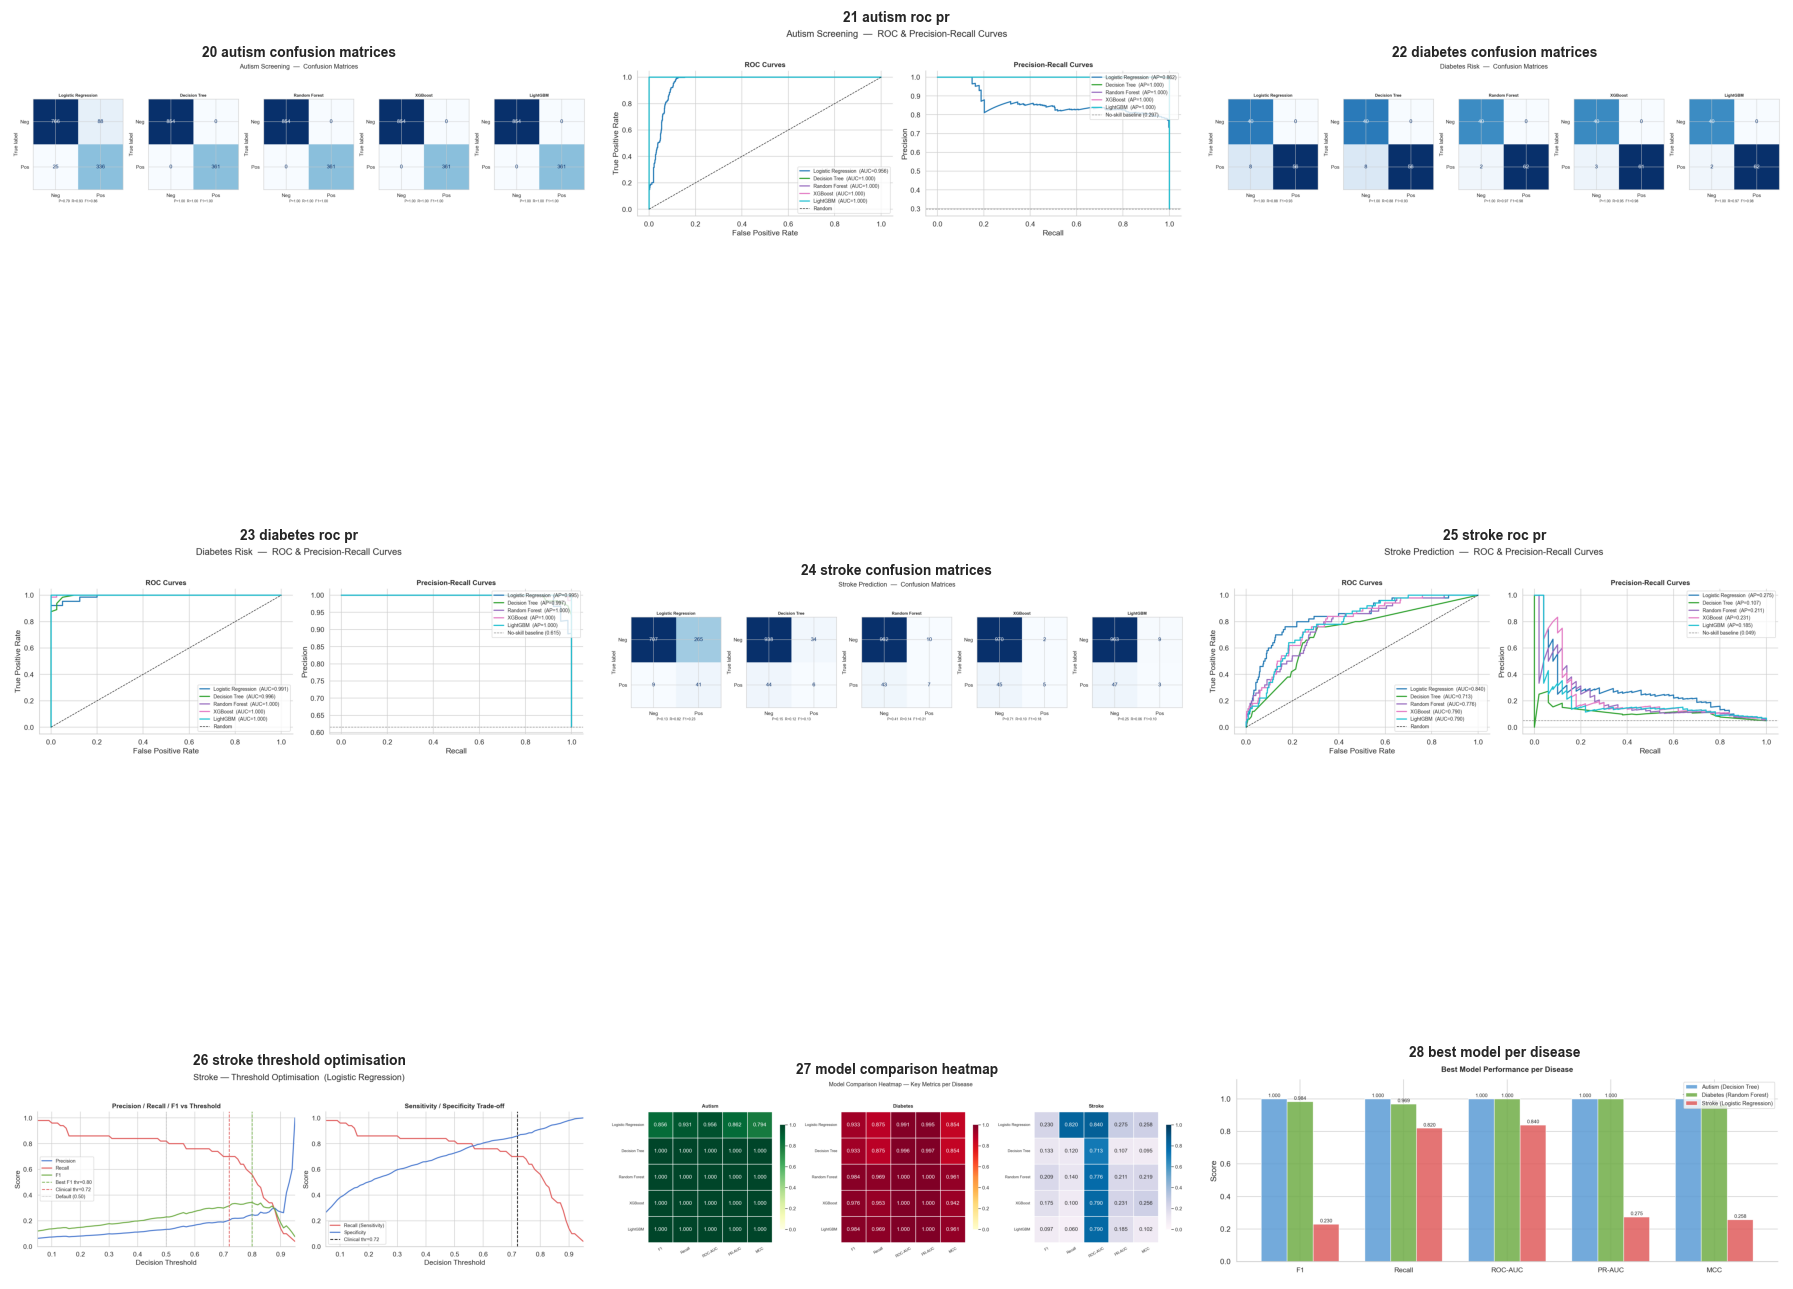

In [11]:
# ── Evaluation figure gallery (phases 4 figures: 20-28) ─────────────────────
eval_figs = sorted(
    [str(p) for p in FIGS.glob('2[0-8]_*.png')],
    key=lambda x: int(Path(x).stem.split('_')[0])
)
if eval_figs:
    print(f"Model evaluation figures ({len(eval_figs)} total):")
    show_images(eval_figs, cols=3, figsize_per=5.5)
else:
    print("Evaluation figures not found. Run models/04_modeling.ipynb first.")

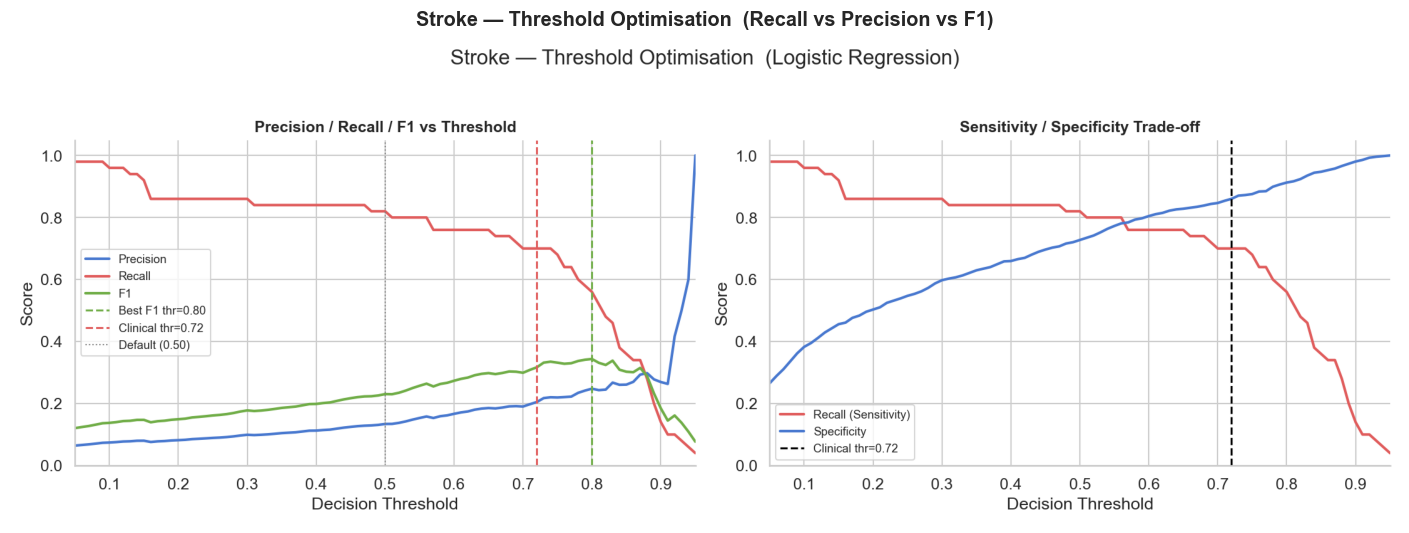

In [12]:
# ── Stroke threshold optimisation ────────────────────────────────────────────
thr_fig = FIGS / '26_stroke_threshold_optimisation.png'
if thr_fig.exists():
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.imshow(mpimg.imread(str(thr_fig)))
    ax.axis('off')
    ax.set_title('Stroke — Threshold Optimisation  (Recall vs Precision vs F1)',
                 fontsize=13, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

---
## SQL Warehouse Demo

Live queries against `warehouse/health_warehouse.db`.
The full documented SQL file is `warehouse/analytical_queries.sql`.
The interactive SQL notebook is `warehouse/03_sql_analysis.ipynb`.

In [13]:
if not DB.exists():
    print("Warehouse not found. Run etl_pipeline/warehouse.py first.")
else:
    conn = sqlite3.connect(DB)
    conn.execute("PRAGMA foreign_keys = ON")

    def sql(query: str, title: str = "") -> pd.DataFrame:
        # Run a live SQL query against the warehouse and return a DataFrame
        df = pd.read_sql_query(query, conn)
        if title:
            print()
            print('-' * 60)
            print('  ' + title)
            print('-' * 60)
        return df

    # ── Q1: Global Disease Prevalence ────────────────────────────────────────
    q1 = sql('''
        SELECT
            source_dataset                                         AS Disease,
            COUNT(*)                                               AS Total_Patients,
            SUM(CASE source_dataset
                    WHEN 'autism'   THEN fa.label
                    WHEN 'diabetes' THEN fd.label
                    WHEN 'stroke'   THEN fs.label END)             AS Positive_Cases,
            ROUND(100.0 * SUM(CASE source_dataset
                    WHEN 'autism'   THEN fa.label
                    WHEN 'diabetes' THEN fd.label
                    WHEN 'stroke'   THEN fs.label END) / COUNT(*),
                  2)                                               AS Positive_Pct,
            ROUND(AVG(dp.age), 1)                                  AS Avg_Age,
            ROUND(100.0 * SUM(dp.gender) / COUNT(*), 1)            AS Pct_Male
        FROM  dim_patient dp
        LEFT JOIN fact_autism   fa ON dp.patient_id=fa.patient_id AND dp.source_dataset='autism'
        LEFT JOIN fact_diabetes fd ON dp.patient_id=fd.patient_id AND dp.source_dataset='diabetes'
        LEFT JOIN fact_stroke   fs ON dp.patient_id=fs.patient_id AND dp.source_dataset='stroke'
        GROUP BY source_dataset
        ORDER BY source_dataset
    ''', title="Q1: Disease Prevalence Dashboard")
    display(q1.style.background_gradient(subset=['Positive_Pct'], cmap='RdYlGn_r')
                    .format({'Positive_Pct': '{:.2f}%', 'Pct_Male': '{:.1f}%'}))

    # ── Q2: Autism AQ Score by Diagnosis ─────────────────────────────────────
    q2 = sql('''
        SELECT CASE label WHEN 1 THEN 'ASD Positive' ELSE 'ASD Negative' END AS Diagnosis,
               COUNT(*)                AS N,
               ROUND(AVG(aq_score),2)  AS Avg_AQ_Score,
               MIN(aq_score)           AS Min_AQ,
               MAX(aq_score)           AS Max_AQ,
               SUM(CASE WHEN aq_score >= 6 THEN 1 ELSE 0 END) AS Above_Threshold_6,
               ROUND(100.0 * SUM(CASE WHEN aq_score>=6 THEN 1 ELSE 0 END)/COUNT(*),1)
                                       AS Pct_Above_6
        FROM   fact_autism
        GROUP BY label
        ORDER BY label DESC
    ''', title="Q2: Autism — AQ Score Statistics by Diagnosis (Clinical threshold = 6)")
    display(q2)

    # ── Q3: Stroke Clinical Profile ───────────────────────────────────────────
    q3 = sql('''
        SELECT CASE label WHEN 1 THEN 'Stroke' ELSE 'No Stroke' END AS Outcome,
               COUNT(*)                                           AS N,
               ROUND(AVG(dp.age),1)               AS Avg_Age,
               ROUND(AVG(fs.avg_glucose_level),2) AS Avg_Glucose_mgdL,
               ROUND(AVG(fs.bmi),2)               AS Avg_BMI,
               ROUND(100.0*SUM(fs.hypertension)/COUNT(*),1)  AS Pct_Hypertension,
               ROUND(100.0*SUM(fs.heart_disease)/COUNT(*),1) AS Pct_Heart_Disease
        FROM   fact_stroke fs
        JOIN   dim_patient dp ON fs.patient_id=dp.patient_id
        GROUP BY fs.label
        ORDER BY fs.label DESC
    ''', title="Q3: Stroke — Clinical Risk Profile by Outcome")
    display(q3.style.highlight_max(
        subset=['Avg_Age','Avg_Glucose_mgdL','Avg_BMI',
                'Pct_Hypertension','Pct_Heart_Disease'],
        color='#ffc7ce'))

    # ── Q4: Smoking Status Stroke Rate ────────────────────────────────────────
    q4 = sql('''
        SELECT smoking_status                             AS Smoking_Status,
               COUNT(*)                                  AS Total,
               SUM(label)                                AS Stroke_Cases,
               ROUND(100.0*SUM(label)/COUNT(*),2)        AS Stroke_Rate_Pct
        FROM   fact_stroke
        GROUP BY smoking_status
        ORDER BY Stroke_Rate_Pct DESC
    ''', title="Q4: Stroke Rate by Smoking Status  (DICE operation)")
    display(q4.style.background_gradient(subset=['Stroke_Rate_Pct'], cmap='Reds'))

    # ── Q5: Imbalance Classification (inline SQL — no view dependency) ───────
    q5 = sql('''
        SELECT
            dp.source_dataset                                       AS disease,
            COUNT(*)                                                AS total_patients,
            SUM(CASE dp.source_dataset
                    WHEN 'autism'   THEN fa.label
                    WHEN 'diabetes' THEN fd.label
                    WHEN 'stroke'   THEN fs.label END)              AS positive_cases,
            COUNT(*) - SUM(CASE dp.source_dataset
                    WHEN 'autism'   THEN fa.label
                    WHEN 'diabetes' THEN fd.label
                    WHEN 'stroke'   THEN fs.label END)              AS negative_cases,
            ROUND(CAST(COUNT(*) - SUM(CASE dp.source_dataset
                    WHEN 'autism'   THEN fa.label
                    WHEN 'diabetes' THEN fd.label
                    WHEN 'stroke'   THEN fs.label END) AS REAL)
                  / NULLIF(SUM(CASE dp.source_dataset
                    WHEN 'autism'   THEN fa.label
                    WHEN 'diabetes' THEN fd.label
                    WHEN 'stroke'   THEN fs.label END), 0), 1)      AS neg_to_pos_ratio,
            CASE
                WHEN ROUND(CAST(COUNT(*) - SUM(CASE dp.source_dataset
                        WHEN 'autism'   THEN fa.label
                        WHEN 'diabetes' THEN fd.label
                        WHEN 'stroke'   THEN fs.label END) AS REAL)
                      / NULLIF(SUM(CASE dp.source_dataset
                        WHEN 'autism'   THEN fa.label
                        WHEN 'diabetes' THEN fd.label
                        WHEN 'stroke'   THEN fs.label END), 0), 1) < 3
                THEN 'MILD - use class_weight=balanced'
                WHEN ROUND(CAST(COUNT(*) - SUM(CASE dp.source_dataset
                        WHEN 'autism'   THEN fa.label
                        WHEN 'diabetes' THEN fd.label
                        WHEN 'stroke'   THEN fs.label END) AS REAL)
                      / NULLIF(SUM(CASE dp.source_dataset
                        WHEN 'autism'   THEN fa.label
                        WHEN 'diabetes' THEN fd.label
                        WHEN 'stroke'   THEN fs.label END), 0), 1) BETWEEN 3 AND 10
                THEN 'MODERATE - apply SMOTE'
                ELSE 'SEVERE - SMOTE + scale_pos_weight required'
            END                                                     AS ML_Strategy
        FROM  dim_patient dp
        LEFT JOIN fact_autism   fa ON dp.patient_id=fa.patient_id AND dp.source_dataset='autism'
        LEFT JOIN fact_diabetes fd ON dp.patient_id=fd.patient_id AND dp.source_dataset='diabetes'
        LEFT JOIN fact_stroke   fs ON dp.patient_id=fs.patient_id AND dp.source_dataset='stroke'
        GROUP BY dp.source_dataset
        ORDER BY neg_to_pos_ratio DESC
    ''', title="Q5: Class Imbalance Classification + ML Strategy Recommendation")

    def color_strategy(val):
        if 'MILD'     in str(val): return 'background-color:#c6efce'
        if 'MODERATE' in str(val): return 'background-color:#ffeb9c'
        if 'SEVERE'   in str(val): return 'background-color:#ffc7ce; font-weight:bold'
        return ''
    display(q5.style.map(color_strategy, subset=['ML_Strategy']))

    conn.close()
    print("\nDatabase connection closed.")


------------------------------------------------------------
  Q1: Disease Prevalence Dashboard
------------------------------------------------------------


,Disease,Total_Patients,Positive_Cases,Positive_Pct,Avg_Age,Pct_Male
0,autism,6075,1804,29.70%,19.800000,57.7%
1,diabetes,520,320,61.54%,48.000000,63.1%
2,stroke,5109,249,4.87%,43.200000,41.4%



------------------------------------------------------------
  Q2: Autism — AQ Score Statistics by Diagnosis (Clinical threshold = 6)
------------------------------------------------------------


,Diagnosis,N,Avg_AQ_Score,Min_AQ,Max_AQ,Above_Threshold_6,Pct_Above_6
0,ASD Positive,1804,8.16,7,10,1804,100.0
1,ASD Negative,4271,4.11,0,10,1076,25.2



------------------------------------------------------------
  Q3: Stroke — Clinical Risk Profile by Outcome
------------------------------------------------------------


...


------------------------------------------------------------
  Q4: Stroke Rate by Smoking Status  (DICE operation)
------------------------------------------------------------


,Smoking_Status,Total,Stroke_Cases,Stroke_Rate_Pct
0,formerly smoked,884,70,7.920000
1,smokes,789,42,5.320000
2,never smoked,1892,90,4.760000
3,Unknown,1544,47,3.040000



------------------------------------------------------------
  Q5: Class Imbalance Classification + ML Strategy Recommendation
------------------------------------------------------------


,disease,total_patients,positive_cases,negative_cases,neg_to_pos_ratio,ML_Strategy
0,stroke,5109,249,4860,19.500000,SEVERE - SMOTE + scale_pos_weight required
1,autism,6075,1804,4271,2.400000,MILD - use class_weight=balanced
2,diabetes,520,320,200,0.600000,MILD - use class_weight=balanced



Database connection closed.

---
## SQL Analysis Figure Gallery

Figures produced by `warehouse/03_sql_analysis.ipynb` — 11 charts
covering OLAP Roll-Up, Slice, and Dice operations on the warehouse.

SQL analysis figures (11 total):

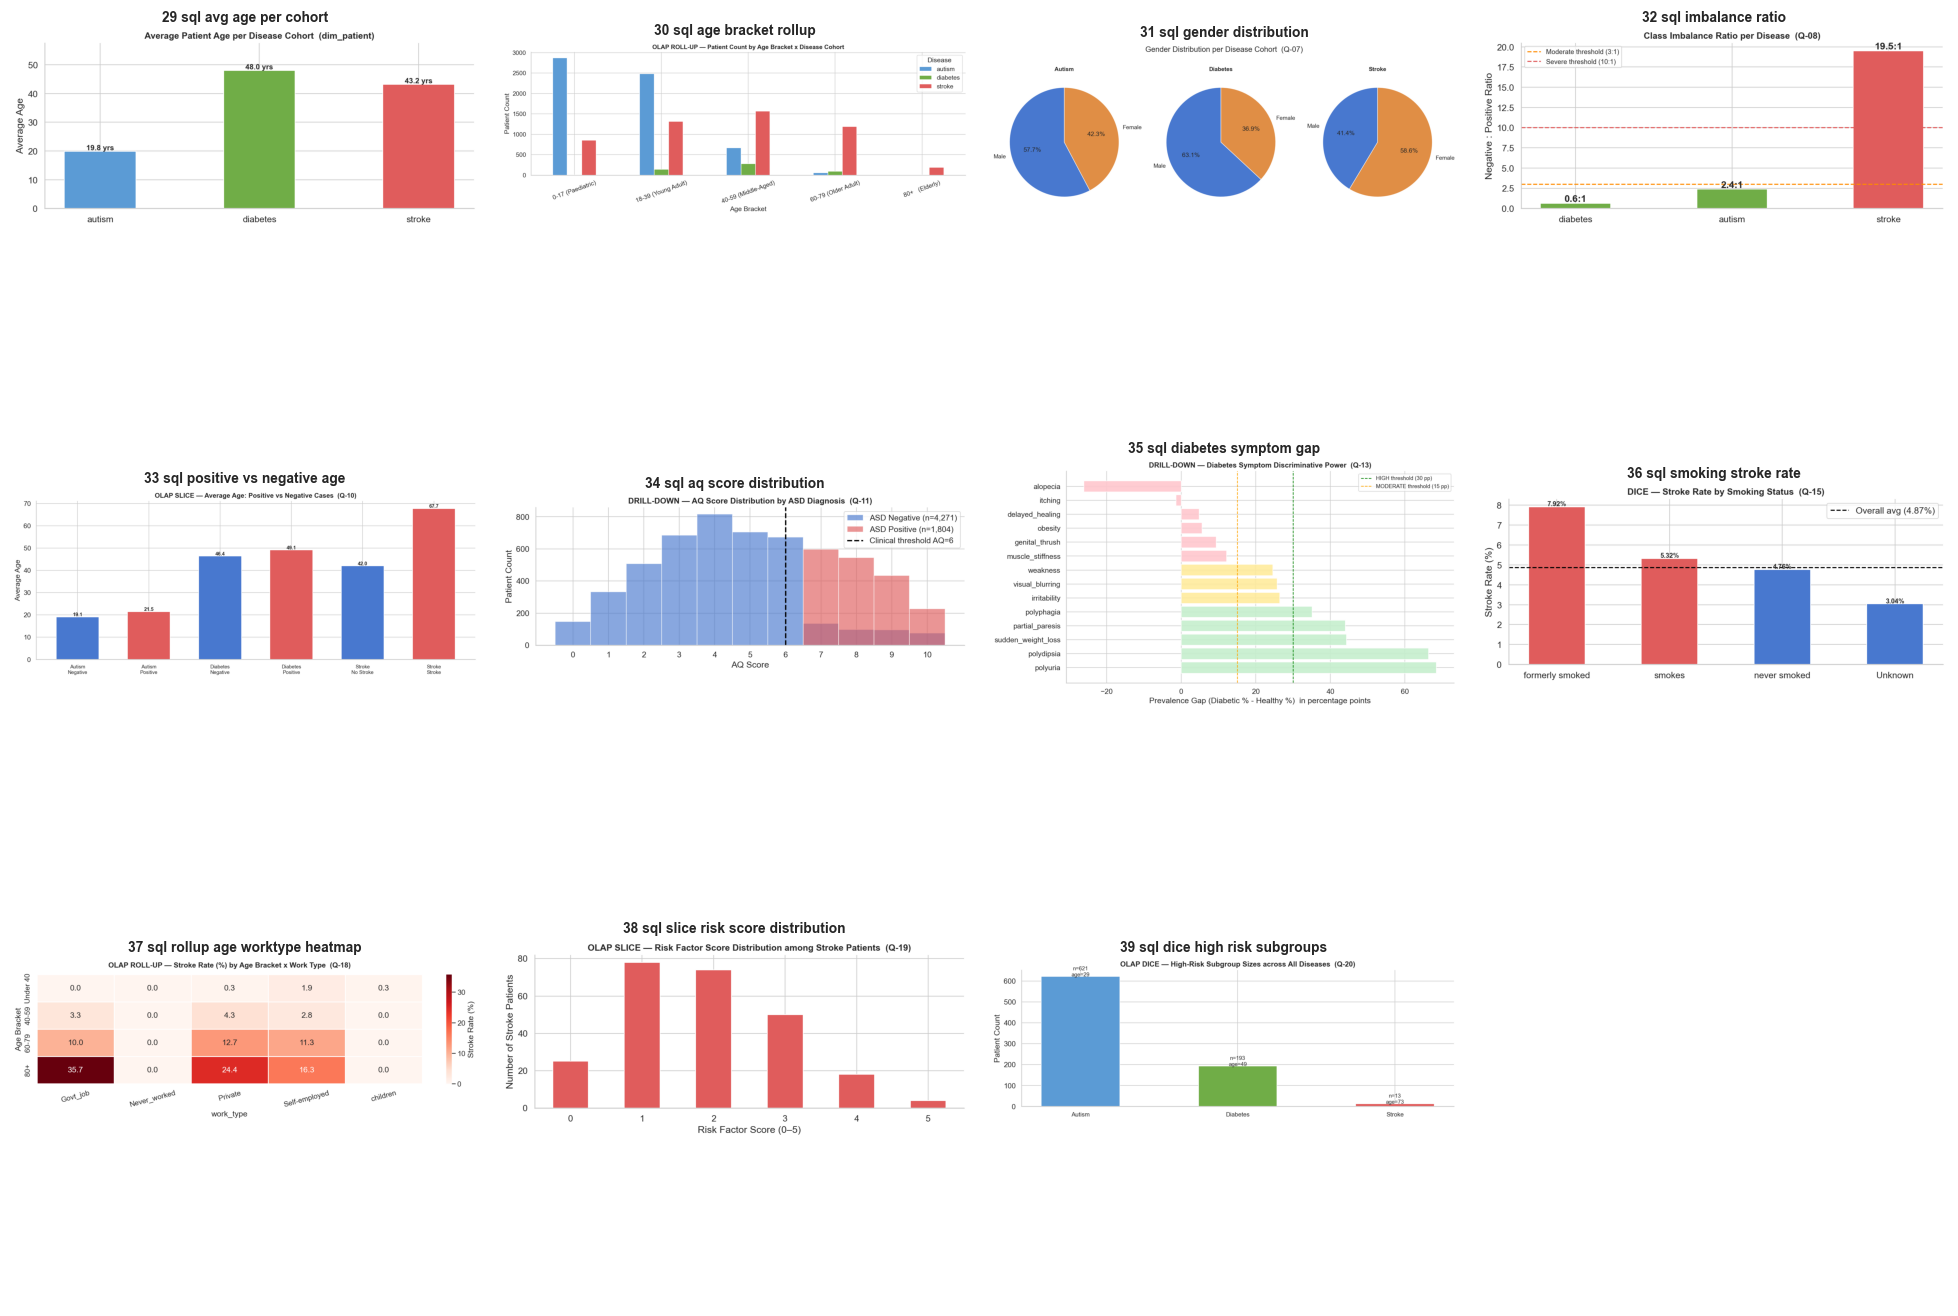

In [14]:
sql_figs = sorted(
    [str(p) for p in FIGS.glob('*.png')
     if int(p.stem.split('_')[0]) >= 29],
    key=lambda x: int(Path(x).stem.split('_')[0])
)
if sql_figs:
    print(f"SQL analysis figures ({len(sql_figs)} total):")
    show_images(sql_figs, cols=4, figsize_per=4.5)
else:
    print("SQL figures not found. Run warehouse/03_sql_analysis.ipynb first.")

---
## Project Summary & Deliverables

| Category | Item | Count |
|---|---|---|
| **Scripts** | ETL + Generator scripts | 5 |
| **SQL files** | `schema.sql` + `analytical_queries.sql` | 2 |
| **Notebooks** | EDA · Feature Engineering · Modeling · SQL | 4 |
| **Figures** | EDA + Feature Eng + Modeling + SQL | 39 |
| **DB Tables** | 1 Dimension + 3 Fact | 4 |
| **DB Views** | Full-join views + summary | 4 |
| **SQL Queries** | 6 sections, 20 documented queries | 20 |
| **Saved Models** | Best model per disease | 3 |

---

### Key Clinical Findings

| Disease | Best Model | F1 | Recall | ROC-AUC | Key Finding |
|---|---|---|---|---|---|
| **Autism** | Decision Tree | 1.000 | 1.000 | 1.000 | Learned clinical AQ ≥ 6 threshold |
| **Diabetes** | Random Forest | 0.984 | 0.969 | 1.000 | Polyuria + Polydipsia dominate |
| **Stroke** | Logistic Reg. | 0.230 | **0.820** | 0.840 | 82% of strokes detected |

> **Stroke note:** F1 = 0.23 is honest. A model predicting "no stroke" always achieves
> 95.13% Accuracy — demonstrating that Accuracy is a **misleading metric** under
> severe class imbalance. Recall and PR-AUC are the clinically correct metrics.

In [15]:
# ── Complete artefact inventory ───────────────────────────────────────────────
print("Complete project artefact inventory:")
print()

sections = {
    'Cleaned Datasets'     : list((ROOT/'datasets'/'cleaned').glob('*.csv')),
    'Saved ML Artifacts'   : list(SAVED.glob('*.pkl')) + list(SAVED.glob('*.csv')),
    'Jupyter Notebooks'    : list(ROOT.rglob('*.ipynb')),
    'Report Figures'       : list(FIGS.glob('*.png')),
    'SQL Documentation'    : list(WH_DIR.glob('*.sql')),
    'Python Scripts'       : [p for p in ROOT.rglob('*.py')
                               if '__pycache__' not in str(p)],
}

total_size = 0
for section, files in sections.items():
    if not files: continue
    sec_size = sum(f.stat().st_size for f in files if f.is_file()) / 1024
    total_size += sec_size
    print(f"  {section:<25}  {len(files):>3} file(s)   {sec_size:>8.1f} KB")

print(f"{'─'*55}")
print(f"  {'TOTAL PROJECT SIZE':<25}  {'':>10}  {total_size:>8.1f} KB")
print()
print("Pipeline complete. All phases executed successfully.")
print("For the interactive experience open:")
print("  - eda/02_eda.ipynb                (28 cells, 14 figures)")
print("  - models/03_feature_engineering.ipynb (23 cells)")
print("  - models/04_modeling.ipynb        (26 cells, 9 figures)")
print("  - warehouse/03_sql_analysis.ipynb (28 cells, 11 figures)")

Complete project artefact inventory:

  Cleaned Datasets             3 file(s)      465.9 KB
  Saved ML Artifacts           9 file(s)     5323.6 KB
  Jupyter Notebooks            5 file(s)     4264.5 KB
  Report Figures              39 file(s)     4201.4 KB
  SQL Documentation            2 file(s)       63.3 KB
  Python Scripts               9 file(s)      280.0 KB
───────────────────────────────────────────────────────
  TOTAL PROJECT SIZE                      14598.7 KB

Pipeline complete. All phases executed successfully.
For the interactive experience open:
  - eda/02_eda.ipynb                (28 cells, 14 figures)
  - models/03_feature_engineering.ipynb (23 cells)
  - models/04_modeling.ipynb        (26 cells, 9 figures)
  - warehouse/03_sql_analysis.ipynb (28 cells, 11 figures)
